In [3]:
import sys
from pathlib import Path
repo_root = Path().resolve().parent  
sys.path.append(str(repo_root))

In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error, mean_squared_error
from sklearn.cluster import KMeans
import joblib
import plotly.graph_objects as go
import plotly.express as px 
import plotly.io as pio
import plotly.subplots as sp
from sklearn.pipeline import Pipeline 
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.Tenth_Best_Time_Estimator import TenthBestTimeEstimator
from src.data.Segment_Slicer import SegmentSlicer 
segment_slicer = SegmentSlicer()
from tensorflow import keras
from tensorflow.keras import layers
from xgboost import XGBRegressor
from scipy.optimize import curve_fit

In [5]:
df= pd.read_parquet(repo_root / 'data' / 'processed' / 'reunion_segments_cleaned.parquet')

In [6]:
print(f"📊 Dataset: {len(df)} segments")
print(f"   Running: {(df['activity_type']=='Run').sum()}")
print(f"   Cycling: {(df['activity_type']=='Ride').sum()}")

📊 Dataset: 2848 segments
   Running: 1470
   Cycling: 1378


In [7]:
# Création de la figure avec deux sous-graphiques
fig = sp.make_subplots(rows=2, cols=1,
                    subplot_titles=("Distribution of Effort Counts", "Best Time vs Effort Count"),
                    vertical_spacing=0.15)

# 1. Histogramme (échelle log)
histogram = go.Histogram(
    x=df['total_effort_count'],
    nbinsx=50,
    marker=dict(color='blue', line=dict(color='black', width=1)),
    name='Effort Count'
)
fig.add_trace(histogram, row=1, col=1)

# Ligne de seuil (500)
fig.add_vline(x=500, line=dict(color='red', dash='dash'), row=1, col=1, annotation_text="Threshold (500)", annotation_position="top right")

# Configuration de l'échelle log pour l'axe y
fig.update_yaxes(type="log", row=1, col=1)
fig.update_xaxes(title_text="Total Efforts", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)

# 2. Scatter plot (échelle log pour x, colorbar pour la distance)
scatter = go.Scatter(
    x=df['total_effort_count'],
    y=df['best_time'],
    mode='markers',
    marker=dict(
        size=8,
        color=df['distance']/1000,
        colorscale='Viridis',
        opacity=0.6,
        showscale=True,
        colorbar=dict(title='Distance (km)')
    ),
    name='Best Time'
)
fig.add_trace(scatter, row=2, col=1)

# Configuration des axes pour le scatter plot
fig.update_xaxes(type="log", title_text="Total Efforts", row=2, col=1)
fig.update_yaxes(title_text="Best Time (s)", row=2, col=1)

# Mise en page finale
fig.update_layout(
    height=800,
    width=800,
    showlegend=False,
    title_text="Effort Count Analysis"
)

# Affichage
fig.show()

In [8]:
Train, Test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['activity_type'])
Train, Val = train_test_split(Train, test_size=0.25, random_state=42, stratify=Train['activity_type'])
print(f"Train: {len(Train)}, Val: {len(Val)}, Test: {len(Test)}")

Train: 1708, Val: 570, Test: 570


In [9]:
# Séparer Ride et Run
Train_ride = Train[Train['activity_type'] == 'Ride'].copy()
Train_run = Train[Train['activity_type'] == 'Run'].copy()

Val_ride = Val[Val['activity_type'] == 'Ride'].copy()
Val_run = Val[Val['activity_type'] == 'Run'].copy()

Test_ride = Test[Test['activity_type'] == 'Ride'].copy()
Test_run = Test[Test['activity_type'] == 'Run'].copy()

In [10]:
Train_Val_Test_ride = pd.concat([Train_ride, Val_ride, Test_ride], ignore_index=True)
Train_Val_Test_run = pd.concat([Train_run, Val_run, Test_run], ignore_index=True)

In [11]:
print(f"Train Ride: {len(Train_ride)}, Run: {len(Train_run)}")
print(f"Val Ride: {len(Val_ride)}, Run: {len(Val_run)}")
print(f"Test Ride: {len(Test_ride)}, Run: {len(Test_run)}")

Train Ride: 826, Run: 882
Val Ride: 276, Run: 294
Test Ride: 276, Run: 294


In [12]:
print("columns:", Train_ride.columns.tolist())

columns: ['segment_id', 'name', 'activity_type', 'distance', 'elevation_gain', 'elevation_low', 'elevation_high', 'best_time', 'average_top_10_time', 'tenth_best_time', 'total_effort_count', 'total_athlete_count', 'altitude_profile', 'distance_profile', 'coordinates']


### Physic-based model

In [13]:
def effort_correction_model(total_effort_count, best_time, asymptote_factor=0.95):

    high_effort_mask = total_effort_count > 1000
    
    if high_effort_mask.sum() > 50:
        
        high_effort_data = total_effort_count[high_effort_mask]

        target_high_effort_ratio = 0.92  # évite log(0)
        denominator = 1 - target_high_effort_ratio / asymptote_factor

        if denominator <= 0:
            denominator = 1e-6

        k_param = -np.log(denominator) / np.median(high_effort_data)

        def saturation_curve(effort, k):
            return asymptote_factor * (1 - np.exp(-k * effort))

        correction_factor = saturation_curve(total_effort_count, k_param)
        theoretical_best = best_time * correction_factor

        return theoretical_best, correction_factor
    
    else:
        return best_time * 0.95, np.ones_like(best_time) * 0.95


In [14]:
Train_ride = Train_ride.copy()

total_effort = Train_ride["total_effort_count"].values
best_time    = Train_ride["best_time"].values

theoretical_best, correction_factor = effort_correction_model(
    total_effort_count = total_effort,
    best_time = best_time,
    asymptote_factor = 0.95
)

Train_ride.loc[:, "theoretical_best_time"] = theoretical_best
Train_ride.loc[:, "effort_correction_factor"] = correction_factor


### ML model

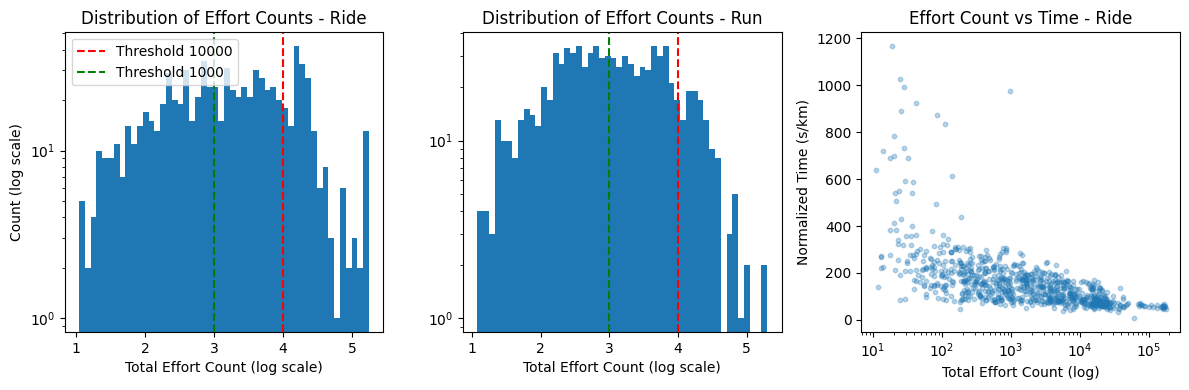

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(np.log10(Train_ride['total_effort_count']), bins=50, log=True)
plt.axvline(np.log10(10000), color='r', linestyle='--', label='Threshold 10000')
plt.axvline(np.log10(1000), color='g', linestyle='--', label='Threshold 1000')
plt.xlabel('Total Effort Count (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Distribution of Effort Counts - Ride')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(np.log10(Train_run['total_effort_count']), bins=50, log=True)
plt.axvline(np.log10(10000), color='r', linestyle='--')
plt.axvline(np.log10(1000), color='g', linestyle='--')
plt.xlabel('Total Effort Count (log scale)')
plt.title('Distribution of Effort Counts - Run')

plt.subplot(1, 3, 3)
# Relation entre effort_count et best_time (normalisé par distance)
Train_ride['norm_time'] = Train_ride['best_time'] / (Train_ride['distance'] / 1000)
plt.scatter(Train_ride['total_effort_count'], Train_ride['norm_time'], 
            alpha=0.3, s=10)
plt.xscale('log')
plt.xlabel('Total Effort Count (log)')
plt.ylabel('Normalized Time (s/km)')
plt.title('Effort Count vs Time - Ride')

plt.tight_layout()
plt.show()

In [16]:
effort_threshold_ride = 1000
effort_threshold_run = 1000

In [17]:
Train_ride_high = Train_ride[Train_ride['total_effort_count'] >= effort_threshold_ride].copy()
Train_run_high = Train_run[Train_run['total_effort_count'] >= effort_threshold_run].copy()
print(f"High-effort segments - Ride: {len(Train_ride_high)}, Run: {len(Train_run_high)}")

High-effort segments - Ride: 466, Run: 437


In [63]:
def extract_features_from_sections(sections, segment_id=None):
    """
    Extrait des features simples à partir des sections d'un segment.
    
    Input: sections (list of dict) - output de segment_slicer.cut_segment()
    Output: dict of features
    """
    
    if not sections or len(sections) == 0:
        return None
    
    # ========== Features Basiques ==========
    total_distance = sum(s['distance'] for s in sections) / 1000  # en km
    total_elevation_gain = sum(s['elevation_gain'] for s in sections)
    total_elevation_loss = sum(s['elevation_loss'] for s in sections)
    
    # Grades
    all_grades = [s['grade'] for s in sections]
    avg_grade = np.mean(all_grades)
    max_grade = max(s['max_grade'] for s in sections)
    min_grade = min(s['min_grade'] for s in sections)
    
    # ========== Features d'Ordre (Capture la Séquence) ==========
    
    # 1. Distribution des montées (early vs late)
    early_third_distance = total_distance * 1000 * 0.33
    late_third_distance = total_distance * 1000 * 0.67
    
    early_climb_gain = sum(s['elevation_gain'] for s in sections 
                           if s['start_distance'] < early_third_distance)
    late_climb_gain = sum(s['elevation_gain'] for s in sections 
                          if s['start_distance'] > late_third_distance)
    
    early_climb_ratio = early_climb_gain / (total_elevation_gain + 1e-6)
    late_climb_ratio = late_climb_gain / (total_elevation_gain + 1e-6)
    
    # 2. Grade pondéré par position (effet fatigue)
    weighted_grade = 0
    for i, s in enumerate(sections):
        position_weight = 1 + (i / len(sections)) * 0.5  # 1.0 à 1.5x
        weighted_grade += s['grade'] * position_weight * s['distance']
    weighted_grade /= (total_distance * 1000)
    
    # 3. Position de la section la plus dure
    hardest_idx = np.argmax([s['grade'] * s['distance'] for s in sections])
    hardest_section_position = hardest_idx / len(sections)  # 0 à 1
    
    # 4. Variabilité du terrain
    grade_variance = np.mean([s['grade_variance'] for s in sections])
    
    # 5. Stats par tiers du segment
    first_third = [s for s in sections if s['start_distance'] < early_third_distance]
    middle_third = [s for s in sections 
                    if early_third_distance <= s['start_distance'] <= late_third_distance]
    last_third = [s for s in sections if s['start_distance'] > late_third_distance]
    
    first_third_avg_grade = np.mean([s['grade'] for s in first_third]) if first_third else 0
    middle_third_avg_grade = np.mean([s['grade'] for s in middle_third]) if middle_third else 0
    last_third_avg_grade = np.mean([s['grade'] for s in last_third]) if last_third else 0
    
    # 6. Compter les types de sections
    n_climbs = sum(1 for s in sections if s['type'] in ['climb', 'uphill'])
    n_descents = sum(1 for s in sections if s['type'] in ['descent', 'downhill'])
    n_flats = sum(1 for s in sections if s['type'] == 'flat')

    # 7. Features lié au data leakage
    best_time = df.loc[df['segment_id'] == segment_id, 'best_time'].iloc[0]
    avg_top_10_time = df.loc[df['segment_id'] == segment_id, 'average_top_10_time'].iloc[0]
    total_effort_count = df.loc[df['segment_id'] == segment_id, 'total_effort_count'].iloc[0]
    inv_total_effort_count = 1 / (total_effort_count + 1e-6)    
    
    # ========== Assembler le dictionnaire de features ==========
    features = {
        # Basiques
        'total_distance_km': total_distance,
        'total_elevation_gain': total_elevation_gain,
        'total_elevation_loss': total_elevation_loss,
        'avg_grade': avg_grade,
        'max_grade': max_grade,
        'min_grade': min_grade,
        'grade_variance': grade_variance,
        
        # Ordre et fatigue
        'early_climb_ratio': early_climb_ratio,
        'late_climb_ratio': late_climb_ratio,
        'weighted_grade': weighted_grade,
        'hardest_section_position': hardest_section_position,
        
        # Tiers
        'first_third_avg_grade': first_third_avg_grade,
        'middle_third_avg_grade': middle_third_avg_grade,
        'last_third_avg_grade': last_third_avg_grade,
        
        # Comptages
        'n_sections': len(sections),
        'n_climbs': n_climbs,
        'n_descents': n_descents,
        'n_flats': n_flats,

        # Data leakage
        #'best_time': best_time,
        #'avg_top_10_time': avg_top_10_time,
        #'total_effort_count': total_effort_count,
        #'inv_total_effort_count': inv_total_effort_count
    }
    
    return features

In [26]:
def extract_features_for_dataframe(df, sections_dict):
    """
    Extrait les features pour tous les segments d'une DataFrame.
    
    Input:
        - df: DataFrame avec les segments (doit avoir une colonne 'id')
        - sections_dict: dict {segment_id: sections} où sections = output de cut_segment
    
    Output:
        - features_df: DataFrame avec les features
        - valid_indices: indices des segments traités avec succès
    """
    
    features_list = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        segment_id = row['segment_id']
        
        # Vérifier si on a les sections pour ce segment
        if segment_id not in sections_dict:
            print(f"Warning: No sections found for segment {segment_id}")
            continue
        
        sections = sections_dict[segment_id]
        
        # Extraire les features
        features = extract_features_from_sections(sections, segment_id=segment_id)
        
        if features is not None:
            features_list.append(features)
            valid_indices.append(idx)
        else:
            print(f"Warning: Could not extract features for segment {segment_id}")
    
    # Créer la DataFrame de features
    features_df = pd.DataFrame(features_list, index=valid_indices)
    
    print(f"✓ Extracted features for {len(features_df)} / {len(df)} segments")
    
    return features_df, valid_indices

In [27]:
def train_and_evaluate_xgboost(X_train, y_train, X_val, y_val, 
                                 effort_train=None, effort_val=None,
                                 model_name="XGBoost"):
    """
    Entraîne un modèle XGBoost et évalue ses performances.
    
    Returns:
        - model: modèle entraîné
        - metrics: dict des métriques
        - predictions: prédictions sur validation
    """
    
    print("\n" + "="*60)
    print(f"TRAINING {model_name}")
    print("="*60)
    
    # ========== Configuration du modèle ==========
    models = {"adaboost": AdaBoostRegressor(
        n_estimators=100,
        learning_rate=0.1,

        random_state=42
    ), 
    
    "rf": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),
 
                     
    }
    model = models["rf"]
    
    # ========== Entraînement ==========
    print(f"Training on {len(X_train)} samples...")
    
    model.fit(X_train, y_train)
    
    # ========== Prédictions ==========
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    # ========== Métriques ==========
    metrics = {}
    
    # Train metrics
    metrics['train_mae'] = mean_absolute_error(y_train, y_pred_train)
    metrics['train_rmse'] = np.sqrt(mean_squared_error(y_train, y_pred_train))
    metrics['train_mape'] = mean_absolute_percentage_error(y_train, y_pred_train) * 100
    
    # Validation metrics
    mask = (effort_val >= effort_threshold_ride)
    metrics['val_mae'] = mean_absolute_error(y_val[mask], y_pred_val[mask])
    metrics['val_rmse'] = np.sqrt(mean_squared_error(y_val[mask], y_pred_val[mask]))
    metrics['val_mape'] = mean_absolute_percentage_error(y_val[mask], y_pred_val[mask]) * 100
    
    # ========== Affichage ==========
    print(f"\n{model_name} - TRAIN Metrics:")
    print(f"  MAE:  {metrics['train_mae']:.2f}s")
    print(f"  RMSE: {metrics['train_rmse']:.2f}s")
    print(f"  MAPE: {metrics['train_mape']:.2f}%")
    
    print(f"\n{model_name} - VALIDATION Metrics (Effort >= {effort_threshold_ride}):")
    print(f"  MAE:  {metrics['val_mae']:.2f}s")
    print(f"  RMSE: {metrics['val_rmse']:.2f}s")
    print(f"  MAPE: {metrics['val_mape']:.2f}%")
    
    return model, metrics, y_pred_train, y_pred_val

In [28]:
def plot_model_evaluation(y_train, y_pred_train, y_val, y_pred_val, 
                          effort_val=None, model_name="XGBoost"):
    """
    Crée des visualisations pour évaluer le modèle.
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ========== Plot 1: Train - Actual vs Predicted ==========
    axes[0, 0].scatter(y_train, y_pred_train, alpha=0.5, s=20)
    axes[0, 0].plot([y_train.min(), y_train.max()], 
                     [y_train.min(), y_train.max()], 
                     'r--', lw=2, label='Perfect prediction')
    axes[0, 0].set_xlabel('Actual Time (s)')
    axes[0, 0].set_ylabel('Predicted Time (s)')
    axes[0, 0].set_title(f'{model_name} - Train Set')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # ========== Plot 2: Validation - Actual vs Predicted ==========
    axes[0, 1].scatter(y_val, y_pred_val, alpha=0.5, s=20, c='green')
    axes[0, 1].plot([y_val.min(), y_val.max()], 
                     [y_val.min(), y_val.max()], 
                     'r--', lw=2, label='Perfect prediction')
    axes[0, 1].set_xlabel('Actual Time (s)')
    axes[0, 1].set_ylabel('Predicted Time (s)')
    axes[0, 1].set_title(f'{model_name} - Validation Set')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # ========== Plot 3: Residuals Distribution ==========
    residuals_train = y_train - y_pred_train
    residuals_val = y_val - y_pred_val
    
    axes[1, 0].hist(residuals_train, bins=30, alpha=0.6, label='Train', color='blue')
    axes[1, 0].hist(residuals_val, bins=30, alpha=0.6, label='Validation', color='green')
    axes[1, 0].axvline(0, color='r', linestyle='--', lw=2)
    axes[1, 0].set_xlabel('Residuals (s)')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Residuals Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # ========== Plot 4: Residuals vs Effort Count (Data Leakage Check) ==========
    if effort_val is not None:
        axes[1, 1].scatter(np.log1p(effort_val), np.abs(residuals_val), 
                          alpha=0.5, s=20, c='green')
        axes[1, 1].set_xlabel('log(effort_count + 1)')
        axes[1, 1].set_ylabel('|Residuals| (s)')
        axes[1, 1].set_title('Data Leakage Check: |Residuals| vs Effort')
        axes[1, 1].grid(alpha=0.3)
        
        # Calculer corrélation
        from scipy.stats import spearmanr
        corr, p_value = spearmanr(np.log1p(effort_val), np.abs(residuals_val))
        axes[1, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}\np-value: {p_value:.4f}',
                        transform=axes[1, 1].transAxes, 
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        if abs(corr) > 0.3:
            axes[1, 1].text(0.05, 0.75, '⚠️ Possible data leakage!',
                           transform=axes[1, 1].transAxes,
                           color='red', fontweight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'Effort data not available',
                       transform=axes[1, 1].transAxes,
                       ha='center', va='center')
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [29]:
def plot_feature_importance(model, feature_names, top_n=15):
    """
    Affiche l'importance des features.
    """
    
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1][:top_n]
    
    plt.figure(figsize=(10, 6))
    plt.title(f'Top {top_n} Feature Importances')
    plt.bar(range(top_n), importance[indices])
    plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("\nTop Features:")
    for i, idx in enumerate(indices[:10], 1):
        print(f"  {i:2d}. {feature_names[idx]:30s}: {importance[idx]:.4f}")

In [33]:
# 1. Préparer les sections_dict (à adapter selon ton code)
sections_dict = {}
for idx, row in Train_Val_Test_ride.iterrows():
    segment_id = row['segment_id']
    # Charger altitude_profile, distance_profile, coordinates
    sections = segment_slicer.cut_segment(row['altitude_profile'], row['distance_profile'], row['coordinates'])
    sections_dict[segment_id] = sections

In [65]:
# 2. Extraire features pour Train high-effort
X_train_ride, valid_idx_train = extract_features_for_dataframe(Train_ride_high, sections_dict)
y_train_ride = Train_ride_high.loc[valid_idx_train, 'best_time']

✓ Extracted features for 466 / 466 segments


In [66]:
# 3. Extraire features pour Validation
X_val_ride, valid_idx_val = extract_features_for_dataframe(Val_ride, sections_dict)
y_val_ride = Val_ride.loc[valid_idx_val, 'best_time']
effort_val_ride = Val_ride.loc[valid_idx_val, 'total_effort_count']

✓ Extracted features for 276 / 276 segments


In [67]:
# 4. Entraîner le modèle
model_ride, metrics_ride, y_pred_train, y_pred_val = train_and_evaluate_xgboost(
    X_train_ride, y_train_ride,
    X_val_ride, y_val_ride,
    effort_val=effort_val_ride,
    model_name="Ride - Theoretical Time"
)


TRAINING Ride - Theoretical Time
Training on 466 samples...

Ride - Theoretical Time - TRAIN Metrics:
  MAE:  52.70s
  RMSE: 171.90s
  MAPE: 24.58%

Ride - Theoretical Time - VALIDATION Metrics (Effort >= 1000):
  MAE:  66.65s
  RMSE: 166.39s
  MAPE: 29.42%


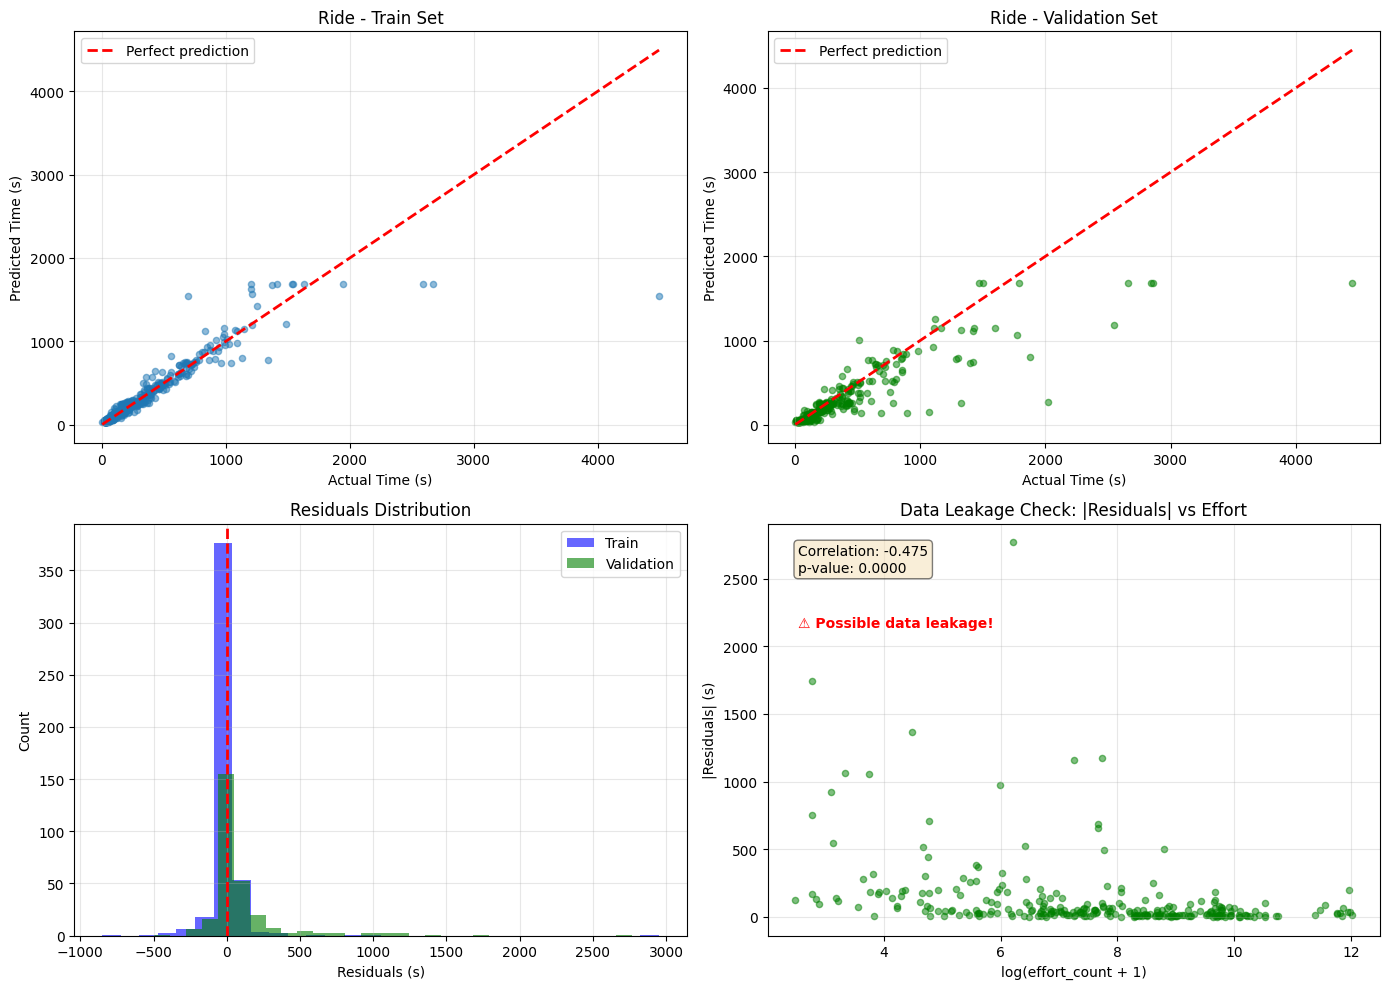

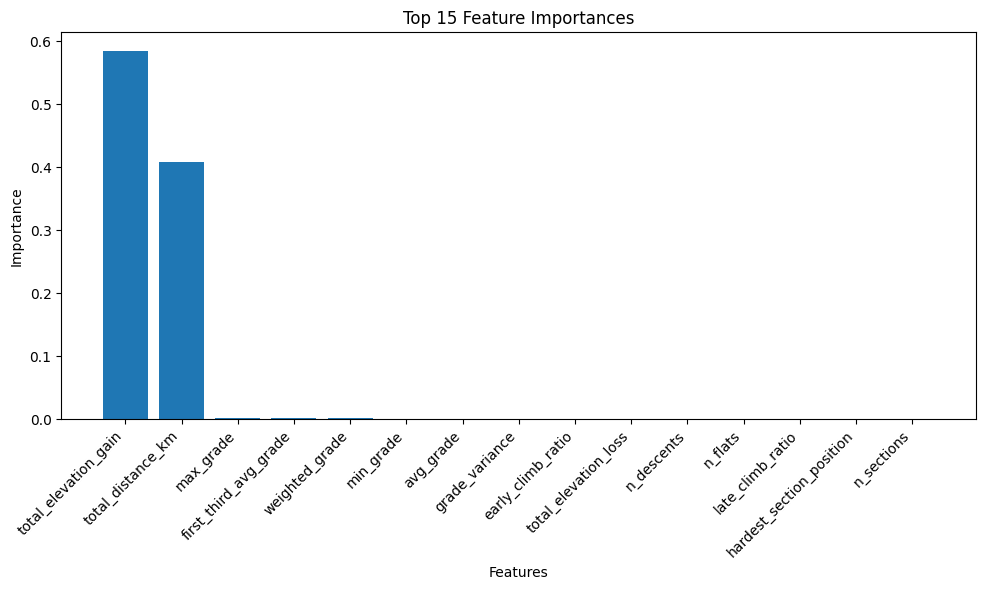


Top Features:
   1. total_elevation_gain          : 0.5848
   2. total_distance_km             : 0.4078
   3. max_grade                     : 0.0025
   4. first_third_avg_grade         : 0.0024
   5. weighted_grade                : 0.0013
   6. min_grade                     : 0.0004
   7. avg_grade                     : 0.0003
   8. grade_variance                : 0.0002
   9. early_climb_ratio             : 0.0001
  10. total_elevation_loss          : 0.0000
✓ Extracted features for 1378 / 1378 segments


In [68]:
# 5. Visualiser
plot_model_evaluation(
    y_train_ride, y_pred_train,
    y_val_ride, y_pred_val,
    effort_val=effort_val_ride,
    model_name="Ride"
)

# 6. Feature importance
plot_feature_importance(model_ride, X_train_ride.columns)

# 7. Prédire pour tous les segments Ride
X_all_ride, valid_idx_all = extract_features_for_dataframe(
    df[df['activity_type'] == 'Ride'], sections_dict
)
df.loc[valid_idx_all, 'theoretical_best_time'] = model_ride.predict(X_all_ride)


#### Correction model

In [40]:
def fit_correction_model(model_terrain, X_all_train, y_all_train, effort_all_train):
    """
    Calibre la fonction de correction basée sur effort_count.
    
    Principe:
    - Prédire avec le modèle de terrain pour TOUS les segments train
    - Calculer ratio = observed / predicted
    - Fitter une fonction: ratio décroît avec effort_count
    - Pour low effort: ratio > 1.0 (observed trop lent)
    - Pour high effort: ratio → 1.0 (observed = theoretical)
    
    Returns:
        - correction_params: (k, asymptote) pour la fonction de correction
    """
    
    # Prédire avec le modèle de terrain
    base_predictions = model_terrain.predict(X_all_train)
    
    # Calculer les ratios: observed / predicted
    ratios = y_all_train / base_predictions
    
    # Filtrer les outliers (ratios aberrants)
    valid_mask = (ratios > 0.5) & (ratios < 2.5) & (effort_all_train > 0)
    ratios_clean = ratios[valid_mask]
    effort_clean = effort_all_train[valid_mask]
    base_pred_clean = base_predictions[valid_mask]
    
    print(f"Using {valid_mask.sum()} / {len(ratios)} samples for correction fitting")
    print(f"Ratio stats: mean={ratios_clean.mean():.3f}, median={np.median(ratios_clean):.3f}")
    
    # Fonction de correction
    def correction_function(effort, k, asymptote):
        """
        Modèle: ratio = 1.0 + (asymptote - 1.0) * exp(-k * effort)
        
        Interprétation:
        - effort → 0:   ratio → asymptote (> 1.0)
        - effort → ∞:   ratio → 1.0
        
        Donc:
        - Low effort: observed = theoretical * asymptote (trop lent)
        - High effort: observed = theoretical * 1.0 (bon)
        """
        return 1.0 + (asymptote - 1.0) * np.exp(-k * effort)
    
    # Fitter les paramètres
    try:
        params, pcov = curve_fit(
            correction_function,
            effort_clean,
            ratios_clean,
            p0=[0.001, 1.2],  # Initial guess: k=0.001, asymptote=1.2
            bounds=([0, 1.0], [0.01, 3.0]),  # k in (0, 0.01), asymptote in (1.0, 3.0)
            maxfev=10000
        )
        
        k, asymptote = params
        
        print(f"\nFitted correction parameters:")
        print(f"  k (decay rate):          {k:.6f}")
        print(f"  asymptote (low-effort):  {asymptote:.3f}")
        print(f"\nInterpretation:")
        print(f"  Segments with 0 efforts:    ratio = {asymptote:.3f} (best_time is {(asymptote-1)*100:.1f}% too slow)")
        print(f"  Segments with 100 efforts:  ratio = {correction_function(100, k, asymptote):.3f}")
        print(f"  Segments with 1000 efforts: ratio = {correction_function(1000, k, asymptote):.3f}")
        
        # Vérifier la qualité du fit
        predicted_ratios = correction_function(effort_clean, k, asymptote)
        r2 = 1 - np.sum((ratios_clean - predicted_ratios)**2) / np.sum((ratios_clean - ratios_clean.mean())**2)
        print(f"\nFit quality: R² = {r2:.3f}")
        
        # Visualiser
        plot_correction_function(effort_clean, ratios_clean, params)
        
        return params
        
    except Exception as e:
        print(f"⚠️  Could not fit correction function: {e}")
        print("Using simple default: theoretical = 0.95 * base_prediction")
        return None

In [41]:
def plot_correction_function(effort_counts, observed_ratios, params):
    """Visualise la fonction de correction"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Points + Courbe
    axes[0].scatter(effort_counts, observed_ratios, alpha=0.3, s=20, label='Observed ratios')
    
    if params is not None:
        k, asymptote = params
        effort_range = np.linspace(0, min(effort_counts.max(), 10000), 1000)
        correction_curve = 1.0 + (asymptote - 1.0) * np.exp(-k * effort_range)
        axes[0].plot(effort_range, correction_curve, 'r-', linewidth=3, 
                    label=f'Fitted: 1 + {asymptote-1:.2f} × exp(-{k:.5f} × effort)')
    
    axes[0].axhline(1.0, color='green', linestyle='--', alpha=0.7, linewidth=2, 
                   label='ratio=1.0 (perfect)')
    axes[0].set_xlabel('Total Effort Count')
    axes[0].set_ylabel('Observed / Predicted Ratio')
    axes[0].set_title('Correction Function: Ratio vs Effort Count')
    axes[0].set_xscale('log')
    axes[0].set_xlim(left=1)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Plot 2: Binned averages
    bins = [0, 50, 100, 200, 500, 1000, 2000, 5000, np.inf]
    bin_labels = ['<50', '50-100', '100-200', '200-500', '500-1k', '1k-2k', '2k-5k', '>5k']
    bin_means = []
    bin_stds = []
    bin_counts = []
    
    for i in range(len(bins)-1):
        mask = (effort_counts >= bins[i]) & (effort_counts < bins[i+1])
        if mask.sum() > 0:
            bin_means.append(observed_ratios[mask].mean())
            bin_stds.append(observed_ratios[mask].std())
            bin_counts.append(mask.sum())
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
            bin_counts.append(0)
    
    x_pos = np.arange(len(bin_labels))
    axes[1].bar(x_pos, bin_means, yerr=bin_stds, alpha=0.7, capsize=5)
    axes[1].axhline(1.0, color='green', linestyle='--', linewidth=2, label='ratio=1.0')
    axes[1].set_xlabel('Effort Count Bins')
    axes[1].set_ylabel('Mean Ratio (± std)')
    axes[1].set_title('Average Ratio by Effort Bins')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(bin_labels, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Annoter avec les counts
    for i, (mean, count) in enumerate(zip(bin_means, bin_counts)):
        if not np.isnan(mean):
            axes[1].text(i, mean + 0.05, f'n={count}', ha='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()


Extracting features for ALL training segments...
✓ Extracted features for 826 / 826 segments
Total train segments for correction: 826
Using 769 / 826 samples for correction fitting
Ratio stats: mean=1.172, median=1.084

Fitted correction parameters:
  k (decay rate):          0.001132
  asymptote (low-effort):  1.626

Interpretation:
  Segments with 0 efforts:    ratio = 1.626 (best_time is 62.6% too slow)
  Segments with 100 efforts:  ratio = 1.559
  Segments with 1000 efforts: ratio = 1.202

Fit quality: R² = 0.387


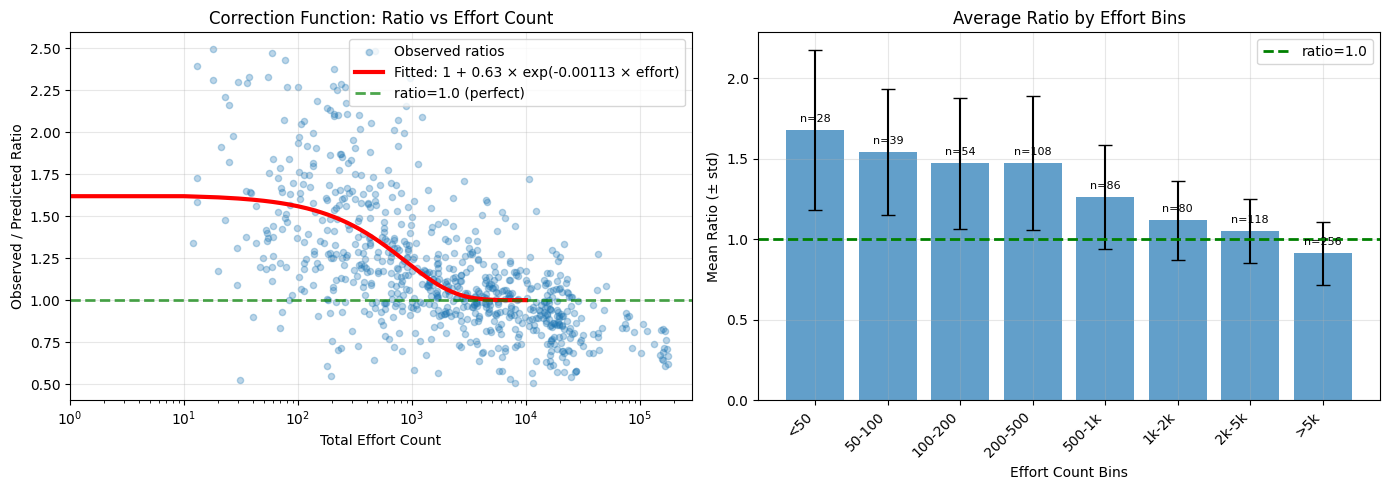

In [69]:
# Préparer les données pour la correction
# On a besoin de TOUS les segments du Train set (pas juste high-effort)
print("\nExtracting features for ALL training segments...")
X_all_train_ride, valid_idx_all_train = extract_features_for_dataframe(Train_ride, sections_dict)
y_all_train_ride = Train_ride.loc[valid_idx_all_train, 'best_time'].values
effort_all_train_ride = Train_ride.loc[valid_idx_all_train, 'total_effort_count'].values

print(f"Total train segments for correction: {len(X_all_train_ride)}")

# Fitter la correction
correction_params_ride = fit_correction_model(
    model_ride, 
    X_all_train_ride, 
    y_all_train_ride, 
    effort_all_train_ride
)

In [46]:
def predict_theoretical_time(model_terrain, X, effort_counts, correction_params):
    """
    Prédit le theoretical_best_time en 2 étapes:
    1. Base prediction (terrain model)
    2. Correction basée sur effort_count
    
    Returns:
        - theoretical_best_time (< observed pour low-effort)
    """
    
    # Stage 1: Prédiction de base (terrain)
    base_predictions = model_terrain.predict(X)
    
    # Stage 2: Correction
    if correction_params is not None:
        k, asymptote = correction_params
        
        # Calculer le facteur de correction pour chaque segment
        correction_ratios = 1.0 + (asymptote - 1.0) * np.exp(-k * effort_counts)
        
        # theoretical = base / correction_ratio
        # Car: observed = theoretical * correction_ratio
        # Donc: theoretical = observed / correction_ratio
        theoretical_predictions = base_predictions / correction_ratios
        
    else:
        # Fallback: correction simple
        theoretical_predictions = base_predictions * 0.95
    
    return theoretical_predictions

In [47]:
print("\n" + "="*60)
print("EVALUATION: FULL MODEL (Terrain + Correction)")
print("="*60)

# Prédire sur validation avec correction
y_pred_val_corrected = predict_theoretical_time(
    model_ride, 
    X_val_ride, 
    effort_val_ride.values, 
    correction_params_ride
)


EVALUATION: FULL MODEL (Terrain + Correction)


In [48]:
def evaluate_theoretical_model(y_observed, y_theoretical, effort_counts, name="Validation"):
    """
    Évalue le modèle theoretical_best_time.
    
    Checks importants:
    1. theoretical <= observed (dans la plupart des cas)
    2. Pour high-effort: theoretical ≈ observed
    3. Pour low-effort: theoretical < observed
    """
    
    print(f"\n{'='*60}")
    print(f"EVALUATION: {name}")
    print(f"{'='*60}")
    
    # Check 1: theoretical <= observed
    ratio = y_observed / y_theoretical
    invalid_count = (ratio < 0.95).sum()
    
    print(f"\nLogic Check:")
    print(f"  Segments where theoretical > observed (ratio < 0.95): {invalid_count} ({invalid_count/len(ratio)*100:.1f}%)")
    print(f"  → Should be close to 0% (theoretical should be ≤ observed)")
    print(f"  Mean ratio (observed/theoretical): {ratio.mean():.3f}")
    print(f"  Median ratio: {np.median(ratio):.3f}")
    
    # Métriques globales
    mae = mean_absolute_error(y_observed, y_theoretical)
    rmse = np.sqrt(mean_squared_error(y_observed, y_theoretical))
    mape = mean_absolute_percentage_error(y_observed, y_theoretical) * 100
    
    print(f"\nGlobal Metrics:")
    print(f"  MAE:  {mae:.2f}s")
    print(f"  RMSE: {rmse:.2f}s")
    print(f"  MAPE: {mape:.2f}%")
    
    # Métriques par strate d'effort
    print(f"\nMetrics by Effort Strata:")
    
    strata = [
        (0, 100, "Very Low"),
        (100, 500, "Low"),
        (500, 1000, "Medium"),
        (1000, 5000, "High"),
        (5000, np.inf, "Very High")
    ]
    
    for low, high, label in strata:
        mask = (effort_counts >= low) & (effort_counts < high)
        if mask.sum() > 0:
            strata_mae = mean_absolute_error(y_observed[mask], y_theoretical[mask])
            strata_mape = mean_absolute_percentage_error(y_observed[mask], y_theoretical[mask]) * 100
            strata_ratio = np.mean(y_observed[mask] / y_theoretical[mask])
            print(f"  {label:12} (n={mask.sum():4}): MAE={strata_mae:6.2f}s, "
                  f"MAPE={strata_mape:5.2f}%, ratio={strata_ratio:.3f}")
    
    return ratio

In [49]:
ratio_val = evaluate_theoretical_model(
    y_val_ride.values, 
    y_pred_val_corrected, 
    effort_val_ride.values,
    name="Validation Ride (Full Model)"
)


EVALUATION: Validation Ride (Full Model)

Logic Check:
  Segments where theoretical > observed (ratio < 0.95): 43 (15.6%)
  → Should be close to 0% (theoretical should be ≤ observed)
  Mean ratio (observed/theoretical): 0.987
  Median ratio: 0.995

Global Metrics:
  MAE:  48.56s
  RMSE: 214.21s
  MAPE: 9.45%

Metrics by Effort Strata:
  Very Low     (n=  27): MAE=106.59s, MAPE=15.46%, ratio=0.948
  Low          (n=  48): MAE= 51.85s, MAPE= 4.66%, ratio=0.996
  Medium       (n=  29): MAE=106.97s, MAPE= 4.68%, ratio=1.053
  High         (n=  73): MAE= 54.86s, MAPE= 5.21%, ratio=1.001
  Very High    (n=  99): MAE=  9.38s, MAPE=14.65%, ratio=0.963


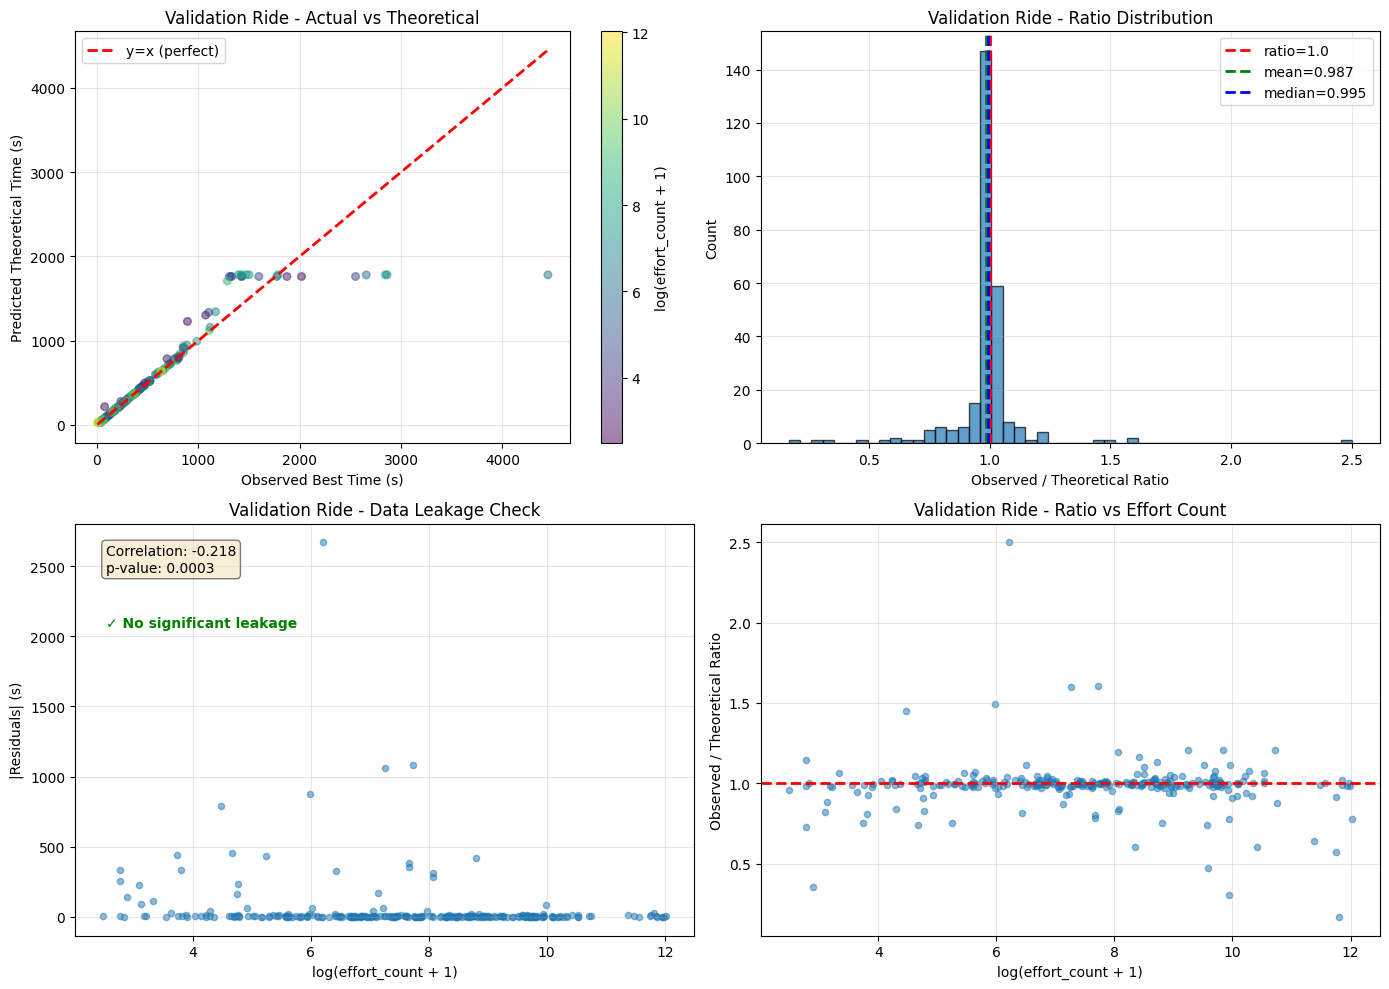

In [50]:
def plot_theoretical_results(y_observed, y_theoretical, effort_counts, name=""):
    """Visualise les résultats du modèle complet"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Actual vs Predicted (coloré par effort)
    scatter = axes[0, 0].scatter(y_observed, y_theoretical, 
                                 alpha=0.5, s=30, 
                                 c=np.log1p(effort_counts), 
                                 cmap='viridis')
    axes[0, 0].plot([y_observed.min(), y_observed.max()], 
                     [y_observed.min(), y_observed.max()], 
                     'r--', lw=2, label='y=x (perfect)')
    axes[0, 0].set_xlabel('Observed Best Time (s)')
    axes[0, 0].set_ylabel('Predicted Theoretical Time (s)')
    axes[0, 0].set_title(f'{name} - Actual vs Theoretical')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[0, 0])
    cbar.set_label('log(effort_count + 1)')
    
    # Plot 2: Ratio distribution
    ratios = y_observed / y_theoretical
    axes[0, 1].hist(ratios, bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='ratio=1.0')
    axes[0, 1].axvline(ratios.mean(), color='green', linestyle='--', linewidth=2, 
                      label=f'mean={ratios.mean():.3f}')
    axes[0, 1].axvline(np.median(ratios), color='blue', linestyle='--', linewidth=2,
                      label=f'median={np.median(ratios):.3f}')
    axes[0, 1].set_xlabel('Observed / Theoretical Ratio')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title(f'{name} - Ratio Distribution')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Plot 3: Residuals vs Effort (leakage check)
    residuals = y_observed - y_theoretical
    axes[1, 0].scatter(np.log1p(effort_counts), np.abs(residuals), alpha=0.5, s=20)
    axes[1, 0].set_xlabel('log(effort_count + 1)')
    axes[1, 0].set_ylabel('|Residuals| (s)')
    axes[1, 0].set_title(f'{name} - Data Leakage Check')
    axes[1, 0].grid(alpha=0.3)
    
    from scipy.stats import spearmanr
    corr, p = spearmanr(np.log1p(effort_counts), np.abs(residuals))
    axes[1, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}\np-value: {p:.4f}',
                   transform=axes[1, 0].transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    if abs(corr) > 0.3:
        axes[1, 0].text(0.05, 0.75, '⚠️ Possible leakage!',
                       transform=axes[1, 0].transAxes, color='red', fontweight='bold')
    else:
        axes[1, 0].text(0.05, 0.75, '✓ No significant leakage',
                       transform=axes[1, 0].transAxes, color='green', fontweight='bold')
    
    # Plot 4: Ratio vs Effort
    axes[1, 1].scatter(np.log1p(effort_counts), ratios, alpha=0.5, s=20)
    axes[1, 1].axhline(1.0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('log(effort_count + 1)')
    axes[1, 1].set_ylabel('Observed / Theoretical Ratio')
    axes[1, 1].set_title(f'{name} - Ratio vs Effort Count')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_theoretical_results(
    y_val_ride.values, 
    y_pred_val_corrected, 
    effort_val_ride.values,
    name="Validation Ride"
)

In [51]:
print("\n" + "="*60)
print("PREDICTING FOR ALL RIDE SEGMENTS")
print("="*60)

# Extraire features pour tous les segments Ride
all_ride_df = Train_Val_Test_ride  # ou df[df['activity_type'] == 'Ride']
X_all_ride, valid_idx_all = extract_features_for_dataframe(all_ride_df, sections_dict)
effort_all_ride = all_ride_df.loc[valid_idx_all, 'total_effort_count'].values

# Prédire
theoretical_times_all = predict_theoretical_time(
    model_ride,
    X_all_ride,
    effort_all_ride,
    correction_params_ride
)

# Ajouter à la DataFrame
all_ride_df.loc[valid_idx_all, 'theoretical_best_time'] = theoretical_times_all

print(f"✓ Predicted theoretical_best_time for {len(valid_idx_all)} Ride segments")
print(f"\nSummary statistics:")
print(f"  Mean theoretical time: {theoretical_times_all.mean():.2f}s")
print(f"  Median theoretical time: {np.median(theoretical_times_all):.2f}s")
print(f"  Min: {theoretical_times_all.min():.2f}s, Max: {theoretical_times_all.max():.2f}s")

# Vérification finale
observed_times = all_ride_df.loc[valid_idx_all, 'best_time'].values
final_ratios = observed_times / theoretical_times_all
print(f"\nFinal ratio check (observed / theoretical):")
print(f"  Mean: {final_ratios.mean():.3f}")
print(f"  Median: {np.median(final_ratios):.3f}")
print(f"  % where ratio < 0.95: {(final_ratios < 0.95).sum() / len(final_ratios) * 100:.1f}%")


PREDICTING FOR ALL RIDE SEGMENTS
✓ Extracted features for 1378 / 1378 segments
✓ Predicted theoretical_best_time for 1378 Ride segments

Summary statistics:
  Mean theoretical time: 414.73s
  Median theoretical time: 242.12s
  Min: 29.64s, Max: 1781.94s

Final ratio check (observed / theoretical):
  Mean: 0.996
  Median: 0.996
  % where ratio < 0.95: 14.4%


In [52]:
first_segment = Train_ride_high.iloc[0]
print(segment_slicer.cut_segment(first_segment['altitude_profile'], first_segment['distance_profile'], first_segment['coordinates'] ))

[{'type': 'flat', 'category': 'Uncategorized', 'start_distance': np.float64(0.0), 'end_distance': np.float64(2097.5), 'distance': np.float64(2097.5), 'start_altitude': np.float64(8.2), 'end_altitude': np.float64(16.9), 'elevation_gain': np.float64(8.7), 'elevation_loss': 0, 'elevation_change': np.float64(8.7), 'grade': np.float64(0.4185305219788044), 'max_grade': np.float64(2.503954895745318), 'min_grade': np.float64(-1.852732212666259), 'grade_variance': np.float64(1.1301758322570103), 'start_idx': 0, 'end_idx': 213}]


### Pro Athlete calibration

In [ ]:
def fit_correction_with_brother_data(brother_segments):
    """
    Calibre la fonction de correction en utilisant les temps de ton frère.
    
    Hypothèse: Ton frère a un niveau constant → son ratio reflète la "difficulté"
    
    Input: brother_segments = DataFrame avec:
        - segment_id
        - best_time (record du segment)
        - brother_time (temps de ton frère)
        - total_effort_count
        
    Output: correction_params (k, asymptote)
    """
    
    print("\n" + "="*60)
    print("CALIBRATION AVEC DONNÉES DU FRÈRE")
    print("="*60)
    
    # Calculer le ratio personnel de ton frère
    brother_segments['brother_ratio'] = brother_segments['brother_time'] / brother_segments['best_time']
    
    print(f"\nAnalyse des {len(brother_segments)} segments de ton frère:")
    print(f"  Ratio moyen: {brother_segments['brother_ratio'].mean():.3f}")
    print(f"  Ratio médian: {brother_segments['brother_ratio'].median():.3f}")
    print(f"  Min: {brother_segments['brother_ratio'].min():.3f}, Max: {brother_segments['brother_ratio'].max():.3f}")
    
    # Hypothèse: Le ratio de ton frère = niveau constant * correction_effort
    # brother_ratio = skill_level * (1 + (asymptote - 1) * exp(-k * effort))
    
    # On veut trouver: quel est son skill_level ?
    # Et quelle est la fonction de correction ?
    
    # Approche: On suppose que pour les segments TRÈS populaires,
    # le best_time est le vrai theoretical → brother_ratio reflète son niveau
    
    high_effort_segments = brother_segments[brother_segments['total_effort_count'] > 2000]
    
    if len(high_effort_segments) > 5:
        skill_level = high_effort_segments['brother_ratio'].median()
        print(f"\nNiveau estimé de ton frère (skill_level): {skill_level:.3f}")
        print(f"  → Il fait en moyenne {(skill_level-1)*100:.1f}% de plus que le record")
    else:
        skill_level = brother_segments['brother_ratio'].median()
        print(f"\n⚠️  Pas assez de segments high-effort, utilise médiane globale: {skill_level:.3f}")
    
    # Normaliser les ratios par le skill level
    brother_segments['normalized_ratio'] = brother_segments['brother_ratio'] 
    
    # Maintenant, normalized_ratio devrait suivre la fonction de correction
    # normalized_ratio = 1 + (asymptote - 1) * exp(-k * effort)
    
    def correction_function(effort, k, asymptote):
        return 1 + (asymptote - 1.0) * np.exp(-k * effort )
    
    # Fitter
    try:
        params, pcov = curve_fit(
            correction_function,
            brother_segments['total_effort_count'],
            brother_segments['normalized_ratio'],
            p0=[0.001, 1.2],
            bounds=([0, 1.0], [0.01, 3.0]),
            maxfev=10000
        )
        
        k, asymptote = params
        
        print(f"\nParamètres de correction fittés:")
        print(f"  k (decay rate): {k:.6f}")
        print(f"  asymptote (low-effort penalty): {asymptote:.3f}")
        
        # Interpréter
        print(f"\nInterprétation:")
        print(f"  Segments avec 0 efforts:    correction = {asymptote:.3f}x")
        print(f"  Segments avec 100 efforts:  correction = {correction_function(100, k, asymptote):.3f}x")
        print(f"  Segments avec 1000 efforts: correction = {correction_function(1000, k, asymptote):.3f}x")
        print(f"  Segments avec 5000 efforts: correction = {correction_function(5000, k, asymptote):.3f}x")
        
        # Visualiser
        plot_brother_calibration(brother_segments, params, skill_level)
        
        return params, skill_level
        
    except Exception as e:
        print(f"⚠️  Échec du fitting: {e}")
        print("Utilise paramètres par défaut")
        return (0.001, 1.3), skill_level

In [ ]:
def plot_brother_calibration(brother_df, params, skill_level):
    """Visualise la calibration avec les données du frère"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Brother ratio vs effort
    axes[0, 0].scatter(brother_df['total_effort_count'], 
                       brother_df['brother_ratio'], 
                       alpha=0.6, s=50)
    axes[0, 0].axhline(skill_level, color='red', linestyle='--', linewidth=2,
                      label=f'Skill level: {skill_level:.3f}')
    axes[0, 0].set_xlabel('Total Effort Count')
    axes[0, 0].set_ylabel('Brother Time / Best Time')
    axes[0, 0].set_title('Ratio du Frère vs Popularité')
    axes[0, 0].set_xscale('log')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: Normalized ratio + fitted curve
    k, asymptote = params
    effort_range = np.linspace(0, brother_df['total_effort_count'].max(), 1000)
    correction_curve = 1.0 + (asymptote - 1.0) * np.exp(-k * effort_range)
    
    axes[0, 1].scatter(brother_df['total_effort_count'], 
                       brother_df['normalized_ratio'],
                       alpha=0.6, s=50, label='Normalized ratios')
    axes[0, 1].plot(effort_range, correction_curve, 'r-', linewidth=3,
                   label=f'Fitted: 1 + {asymptote-1:.2f} × exp(-{k:.5f} × effort)')
    axes[0, 1].axhline(1.0, color='green', linestyle='--', alpha=0.5)
    axes[0, 1].set_xlabel('Total Effort Count')
    axes[0, 1].set_ylabel('Normalized Ratio')
    axes[0, 1].set_title('Fonction de Correction Fittée')
    axes[0, 1].set_xscale('log')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Plot 3: Distribution des ratios
    axes[1, 0].hist(brother_df['brother_ratio'], bins=20, alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(skill_level, color='red', linestyle='--', linewidth=2,
                      label=f'Skill level: {skill_level:.3f}')
    axes[1, 0].set_xlabel('Brother Time / Best Time')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Distribution des Ratios')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: Residuals
    predicted_normalized = 1.0 + (asymptote - 1.0) * (1/np.exp(-k * brother_df['total_effort_count'] + a))
    residuals = brother_df['normalized_ratio'] - predicted_normalized
    
    axes[1, 1].scatter(brother_df['total_effort_count'], residuals, alpha=0.6, s=50)
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('Total Effort Count')
    axes[1, 1].set_ylabel('Residuals')
    axes[1, 1].set_title('Qualité du Fit (Residuals)')
    axes[1, 1].set_xscale('log')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [57]:
def predict_theoretical_with_constraint(model_terrain, X, effort_counts, 
                                        observed_best_times, correction_params,
                                        high_effort_threshold=1000):
    """
    Prédit theoretical_best_time avec contrainte:
    - Pour high-effort: theoretical ≤ observed (cap si nécessaire)
    - Pour low-effort: correction normale
    """
    
    # Stage 1: Prédiction de base
    base_predictions = model_terrain.predict(X)
    
    # Stage 2: Correction
    if correction_params is not None:
        k, asymptote, a = correction_params
        correction_ratios = 1.0 + (asymptote - 1.0) * (1/np.exp(-k * effort_counts + a))
        theoretical_predictions = base_predictions / correction_ratios
    else:
        theoretical_predictions = base_predictions * 0.95
    
    # Stage 3: Contrainte pour high-effort
    high_effort_mask = effort_counts >= high_effort_threshold
    problematic = high_effort_mask & (theoretical_predictions > observed_best_times)
    
    # Cap à observed pour les segments problématiques
    theoretical_predictions[problematic] = observed_best_times[problematic] * 0.99
    # × 0.99 pour être légèrement en dessous (1% de marge)
    
    n_capped = problematic.sum()
    pct_capped = n_capped / len(theoretical_predictions) * 100
    
    print(f"\n⚠️  Constraint applied:")
    print(f"  {n_capped} segments capped ({pct_capped:.1f}%)")
    print(f"  These are high-effort segments where model predicted > observed")
    print(f"  → Set theoretical = 0.99 × observed for these cases")
    
    return theoretical_predictions

   segment_id  best_time  brother_time  total_effort_count
0    38248287        277           277               829.0
1    23271782        370           369               781.0
2     3822906        425           481             18865.0
3    14695295        104           142             42396.0
4    14904081         38            48             44963.0

CALIBRATION AVEC DONNÉES DU FRÈRE

Analyse des 10 segments de ton frère:
  Ratio moyen: 1.183
  Ratio médian: 1.141
  Min: 0.997, Max: 1.487

Niveau estimé de ton frère (skill_level): 1.206
  → Il fait en moyenne 20.6% de plus que le record

Paramètres de correction fittés:
  k (decay rate): 0.001000
  asymptote (low-effort penalty): 1.200

Interprétation:
  Segments avec 0 efforts:    correction = 1.200x
  Segments avec 100 efforts:  correction = 1.000x
  Segments avec 1000 efforts: correction = 1.000x
  Segments avec 5000 efforts: correction = 1.000x


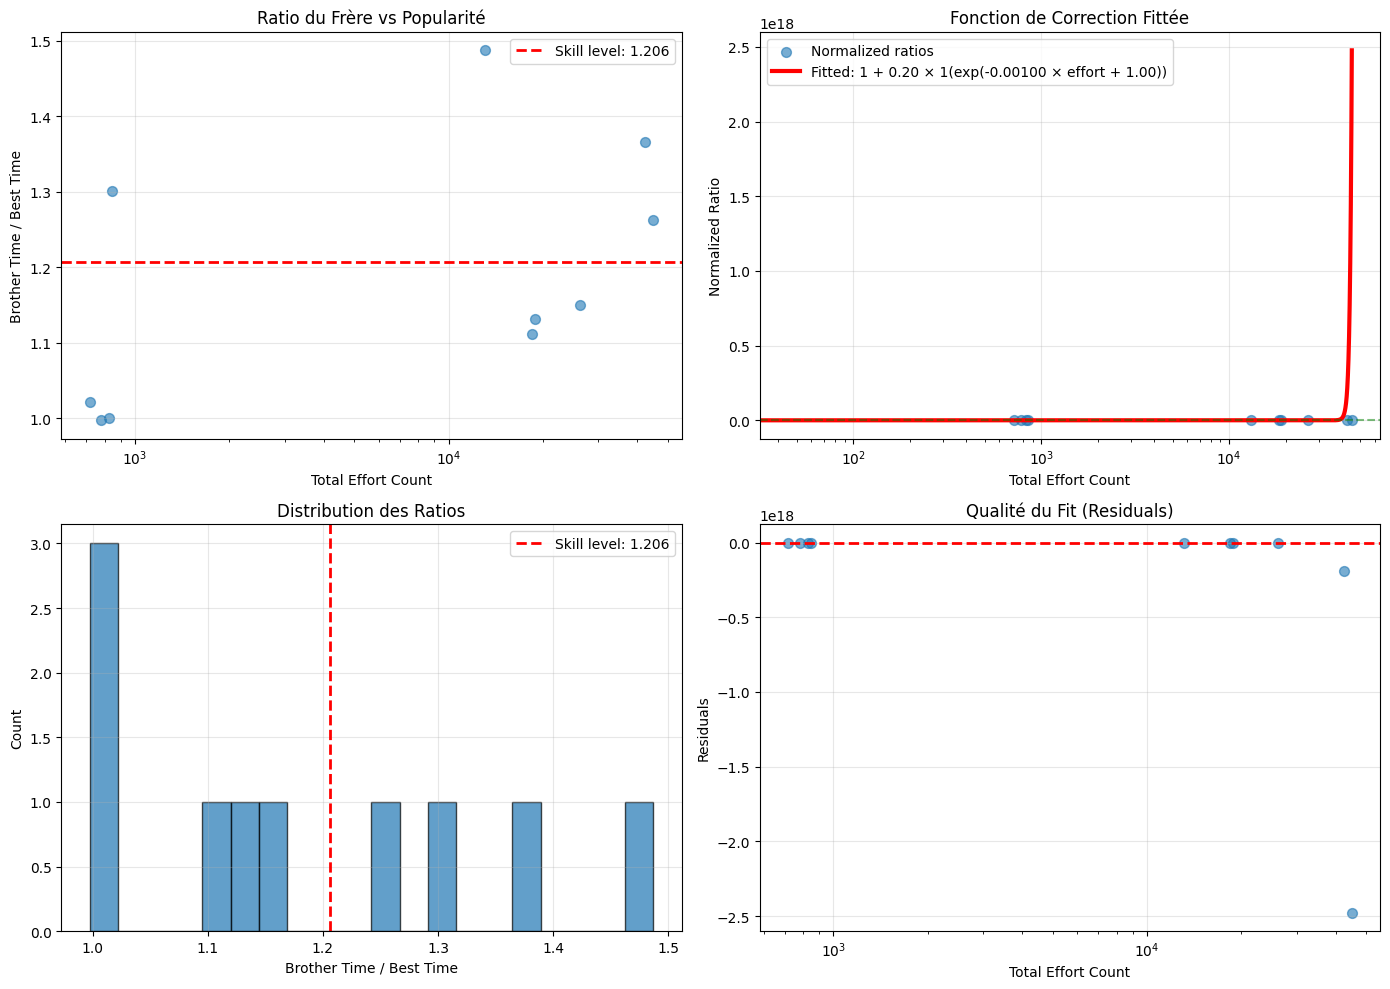

In [62]:
# Préparer les données du frère
matthieu_times = {
    29028548: 19.21,  # segment_id: brother_time (in min.sec)
    17389676: 15.00,
    33021861: 11.36,
    34058866: 2.26,
    14750051: 15.34,
    38248287: 4.37,
    38248290: 4.55,
    23271782: 6.10,
    37895664: 3.40,
    37183010: 6.35,
    23671671: 4.53,
    14750031: 12.46,
    39458362: 19.04,
    39449562: 7.48,
    22750432: 8.23,
    3822906 : 8.02,
    26120689: 11.55,
    14695295: 2.22,
    3933459 : 1.42,
    39294796 : 2.16,
    14904081 : 0.48,
    4426341: 3.52,
    19404993: 10.58,
    3933441: 4.30,
    26738331: 12.07,
    23287499: 11.50
}

  # Exemple de conversion en secondes

brother_segments_list = []

for segment_id, brother_time in matthieu_times.items():
    segment_row = df[df['segment_id'] == segment_id]
    
    if segment_row.empty:
        continue
    
    # ... (Votre logique de conversion de temps) ...
    try:
        minutes = int(brother_time)
        seconds_fraction = (brother_time - minutes) * 100
        brother_time_sec = minutes * 60 + int(seconds_fraction)
    except:
        continue

    # Créer le dictionnaire de la ligne
    new_row_dict = {
        'segment_id': segment_row.iloc[0]['segment_id'],
        'best_time': segment_row.iloc[0]['best_time'],
        'brother_time': brother_time_sec,
        'total_effort_count': segment_row.iloc[0]['total_effort_count']
    }
    
    # 2. Convertir le dictionnaire en un DataFrame d'une ligne
    #    et l'ajouter à la liste.
    #    On utilise [new_row_dict] pour s'assurer que Pandas comprend que
    #    chaque dictionnaire est une LIGNE.
    brother_segments_list.append(pd.DataFrame([new_row_dict]))


# 3. Utiliser pd.concat() une seule fois sur la liste de DataFrames
#    C'est la liste de DataFrames qui est passée, et non la liste de dictionnaires.
brother_segments = pd.concat(brother_segments_list, ignore_index=True)

print(brother_segments.head())

# Calibrer
correction_params_brother, skill_level = fit_correction_with_brother_data(brother_segments)


In [153]:

# Utiliser pour prédire
theoretical_times = predict_theoretical_with_constraint(
    model_ride,
    X_all_ride,
    effort_all_ride,
    observed_best_times,
    correction_params_brother,
    high_effort_threshold=1000
)

NameError: name 'observed_best_times' is not defined